# Rudimentary peak calling

In [ ]:
from pathlib import Path

import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np

import config

In [2]:
modkit_exe = Path("/Users/jeremy/devspace/cargo_local/bin/modkit")
# Starting with 1000bp windows of chr11 as a test (the pileup for the browser happens to be all of chr11)
window_file = Path("/Users/jeremy/devspace/reference_data/beds/chm13v2.0_windows_1000bp/chm13v2.0_windows_1000bp_chr11.bed")
pileup_file = config.processed_data_dir / "pileup.20240923_dimelo_access_background.dorado_v102_sup_v500_5mC_5hmC_v3_6mA_v3.trim.align.filtered.q10.browser" / "pileup.sorted.bed.gz"
output_dir = config.working_dir / "review_data"

In [3]:
output_file = output_dir / "modkit_stats_chr11_1000bp.tsv"
!{modkit_exe} stats {pileup_file} --regions {window_file} -o {output_file}

> Error! File exists (os error 17)


In [4]:
df = pd.read_csv(output_file, sep="\t")[["#chrom", "start", "end", "count_a", "count_valid_a"]]

In [5]:
df

,#chrom,start,end,count_a,count_valid_a
0,chr11,0,1000,645,15396
1,chr11,1000,2000,505,18281
2,chr11,2000,3000,69,12436
3,chr11,3000,4000,163,26293
4,chr11,4000,5000,133,18701
...,...,...,...,...,...
135123,chr11,135123000,135124000,63,9779
135124,chr11,135124000,135125000,9,2880
135125,chr11,135125000,135126000,156,5728
135126,chr11,135126000,135127000,130,6212


Setting background parameters

In [6]:
# Option 1: averages
alpha = np.round(df["count_a"].mean())
beta = np.round(df["count_valid_a"].mean() - alpha)
print(f"alpha: {alpha}, beta: {beta}")

alpha: 40.0, beta: 7944.0


In [7]:
# Option 2: medians
# alpha = df["count_a"].median()
# beta = df["count_valid_a"].median() - alpha
# print(f"alpha: {alpha}, beta: {beta}")

Plot distribution of methylation fractions, and visualize where the estimated background parameters sit

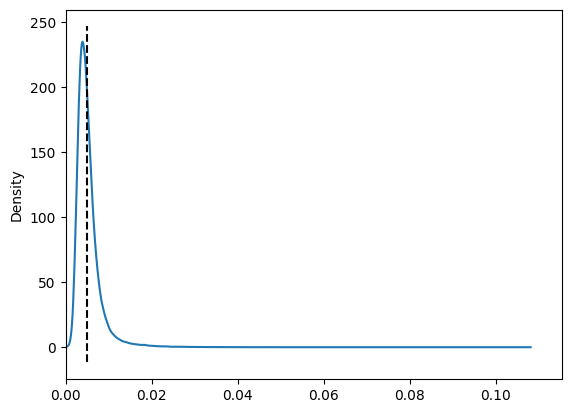

In [8]:
(df["count_a"] / df["count_valid_a"]).plot.kde()
y_min, y_max = plt.ylim()
plt.vlines(alpha / (alpha + beta), y_min, y_max, color="k", linestyle="--")
plt.xlim([0, None])
plt.show()

Sanity check plots for a window of the average size

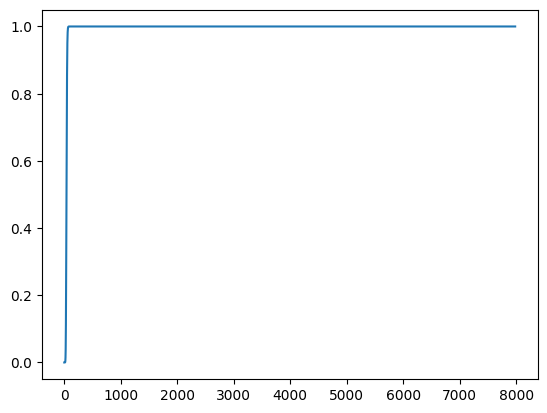

In [9]:
n = int(alpha + beta)
x = np.linspace(0, n, n+1)
y = stats.betabinom.cdf(x, n, alpha, beta)
plt.plot(x, y)

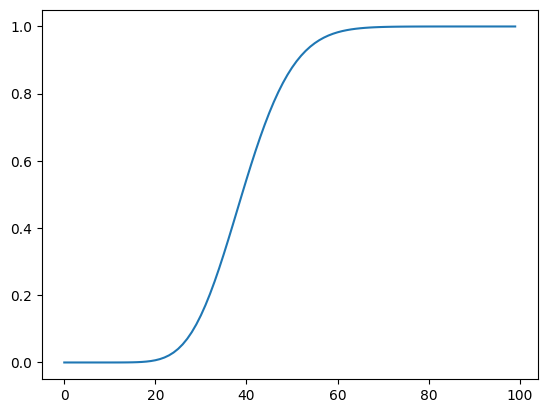

In [10]:
plt.plot(x[:100], y[:100])

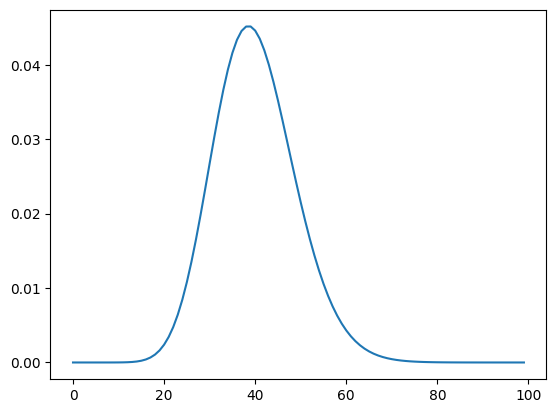

In [11]:
y = stats.betabinom.pmf(x, n, alpha, beta)
plt.plot(x[:100], y[:100])

Applying the test to the data

In [12]:
df["prob"] = df.apply(lambda row: 1 - stats.betabinom.cdf(k=row["count_a"], n=row["count_valid_a"], a=alpha, b=beta), axis="columns")

<Axes: ylabel='Frequency'>

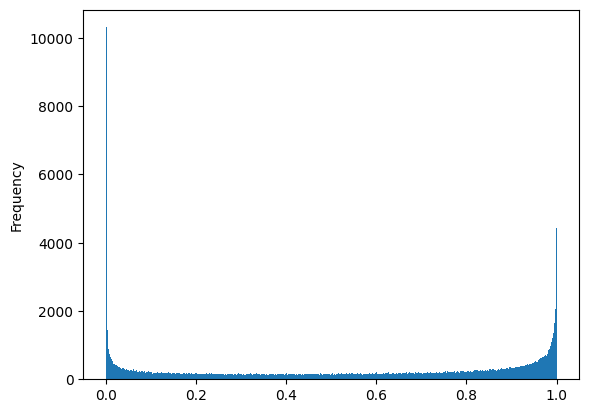

In [13]:
df["prob"].plot.hist(bins=500)

In [14]:
# Fraction of windows detected as peaks
(df["prob"] < 0.05).sum() / len(df)

np.float64(0.1643034752234918)

Save significant windows as a bed file

In [15]:
output_file = output_dir / "chr11_1000bp_significant_windows.bed"
df.query("prob < 0.05")[["#chrom", "start", "end"]].to_csv(output_file, sep="\t", header=False, index=False)

Quick check of overlap/recovery with ChIP-seq peaks (CTCF peaks and TSSs)

In [16]:
chip_seq_file = Path("/Users/jeremy/devspace/multimodal-dimelo/data/processed/gm12878_ctcf.on_target.bed")
dimelo_file = output_dir / "chr11_1000bp_significant_windows.bed"
!bedtools intersect -a {chip_seq_file} -b {dimelo_file} -u | wc -l
!bedtools intersect -a {chip_seq_file} -b {dimelo_file} -v | wc -l

     191
    2809


In [17]:
chip_seq_file = Path("/Users/jeremy/devspace/multimodal-dimelo/data/processed/gm12878_accessibility.on_target.bed")
dimelo_file = output_dir / "chr11_1000bp_significant_windows.bed"
!bedtools intersect -a {chip_seq_file} -b {dimelo_file} -u | wc -l
!bedtools intersect -a {chip_seq_file} -b {dimelo_file} -v | wc -l

     479
    8259


I checked; estimating background with the median has the exact same peak recovery by this very rudimentary metric